In [33]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [34]:
def f1d(x):
    # Rastrigin function 1d
    return 10 + x**2 - 10 * np.cos(2 * np.pi * x)

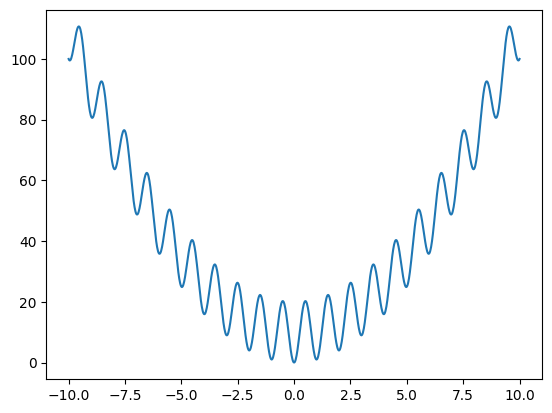

In [35]:
LB = -10
HB = 10

X = np.linspace(LB, HB, 1000)
Y = f1d(X)

YMIN = np.min(Y)
YMAX = np.max(Y)

def plot_f1d():
    global X, Y
    plt.plot(X, Y)
plot_f1d()

In [36]:
N = 20
np.random.seed(100)
pso_particles = np.random.uniform(LB, HB, N)
pso_particles_fitness = f1d(pso_particles)

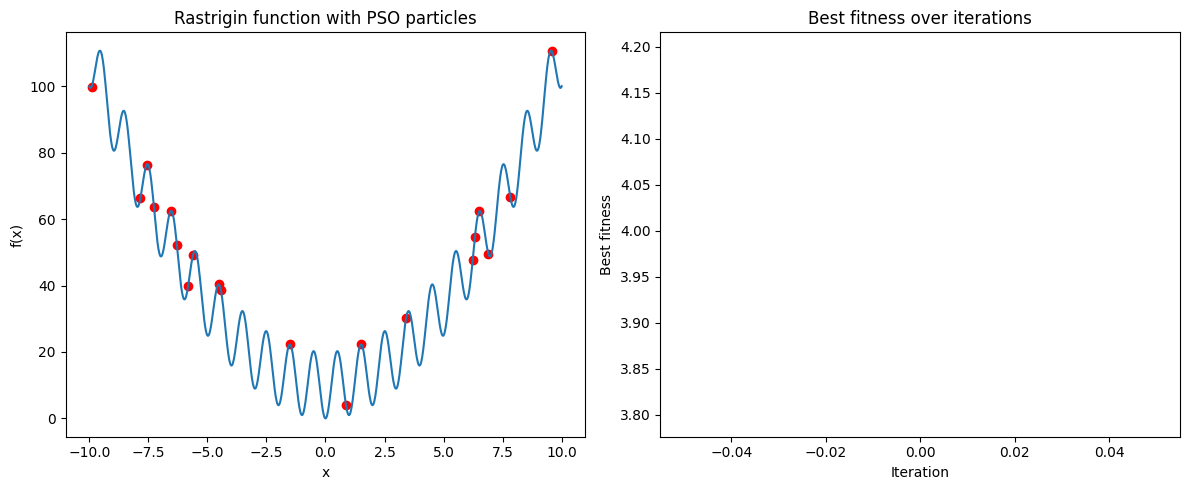

In [37]:
history = []
def plot_f1d_pso():
    global X, Y, pso_particles, pso_particles_fitness
    # two plots f | history
    figure = plt.figure(figsize=(12, 5))
    ax1 = figure.add_subplot(1, 2, 1)
    ax1.plot(X, Y)
    ax1.scatter(pso_particles, pso_particles_fitness, color='red')
    ax1.set_title('Rastrigin function with PSO particles')
    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax2 = figure.add_subplot(1, 2, 2)
    history.append(np.min(pso_particles_fitness))
    ax2.plot(history, color='blue')
    ax2.set_title('Best fitness over iterations')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Best fitness')
    plt.tight_layout() 
plot_f1d_pso()

In [38]:
pso_particles_vel = np.random.uniform(-1, 1, N)
pso_particles_pbest = pso_particles.copy()
pso_particles_pbest_fitness = pso_particles_fitness.copy()
pso_global_best_pos = pso_particles[np.argmin(pso_particles_fitness)]
pso_global_best_fitness = np.min(pso_particles_fitness)

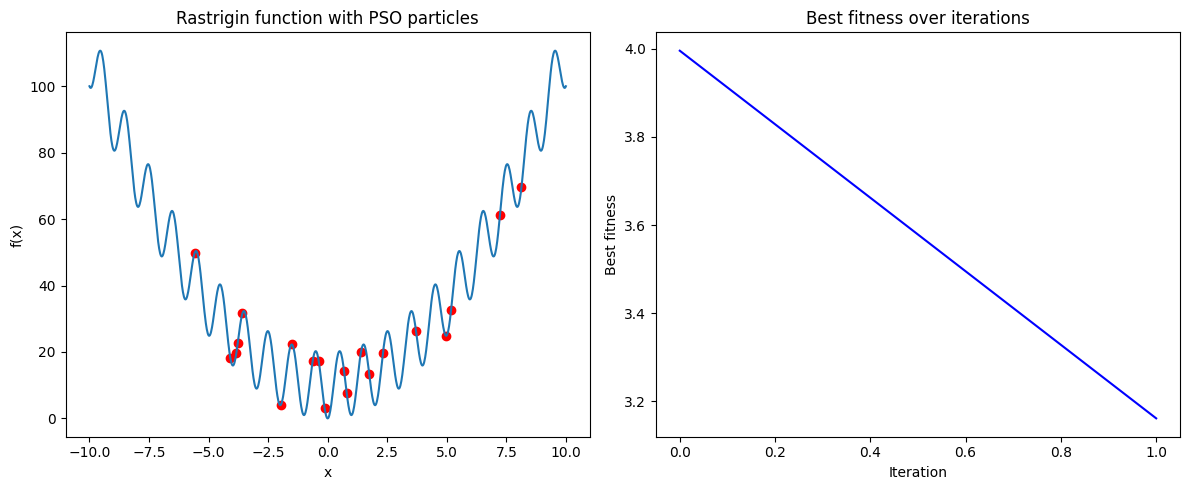

In [39]:
w = 0.5
C1 = 1.8
C2 = 2
for i in range(N):
    # PSO equations
    pso_particles_vel[i] = w * pso_particles_vel[i] + \
                           C1 * (pso_particles_pbest[i] - pso_particles[i]) * np.random.random() + \
                           C2 * (pso_global_best_pos - pso_particles[i]) * np.random.random()
    pso_particles[i] += pso_particles_vel[i]
    pso_particles_fitness[i] = f1d(pso_particles[i])
    if pso_particles_fitness[i] < pso_particles_pbest_fitness[i]:
        pso_particles_pbest[i] = pso_particles[i]
        pso_particles_pbest_fitness[i] = pso_particles_fitness[i]
        if pso_particles_pbest_fitness[i] < pso_global_best_fitness:
            pso_global_best_pos = pso_particles_pbest[i]
            pso_global_best_fitness = pso_particles_pbest_fitness[i]
plot_f1d_pso()

<Figure size 640x480 with 0 Axes>

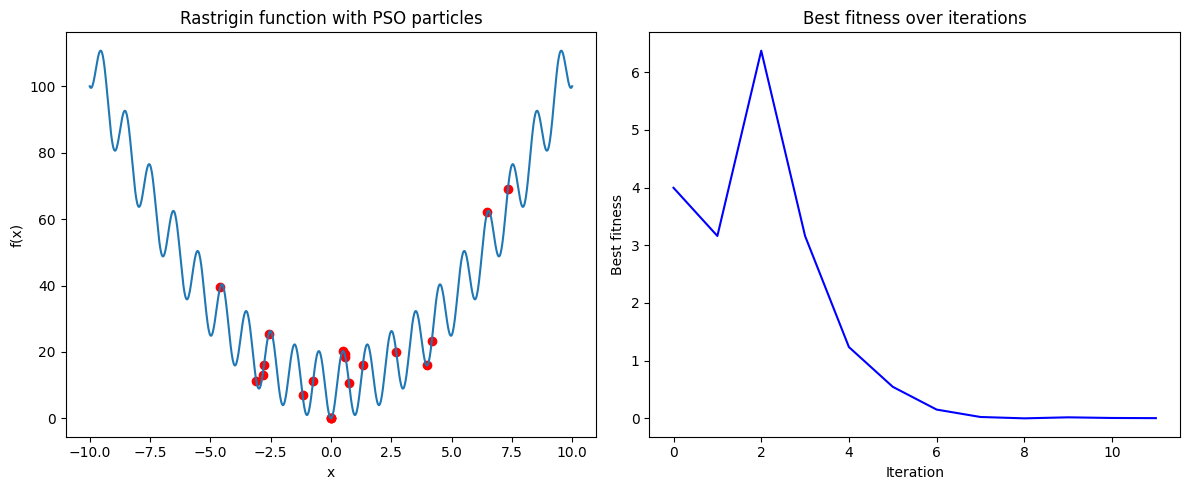

Global best fitness: 0.000006 at position 0.000173 after 11 iterations


In [40]:
max_vel = 0.1
for k in range(100):
    for i in range(N):
        # PSO equations
        pso_particles_vel[i] = 0.5 * pso_particles_vel[i] + \
                            1.8 * (pso_global_best_pos - pso_particles[i]) * np.random.random() + \
                            2 * (pso_particles_pbest[i] - pso_particles[i]) * np.random.random()
        # len of velocity vector is limited to max_vel
        len_vel = np.linalg.norm(pso_particles_vel[i])
        if len_vel > max_vel:
            pso_particles_vel[i] = pso_particles_vel[i] / len_vel * max_vel
        pso_particles[i] += pso_particles_vel[i]
        pso_particles_fitness[i] = f1d(pso_particles[i])
        if pso_particles_fitness[i] < pso_particles_pbest_fitness[i]:
            pso_particles_pbest[i] = pso_particles[i]
            pso_particles_pbest_fitness[i] = pso_particles_fitness[i]
            if pso_particles_pbest_fitness[i] < pso_global_best_fitness:
                pso_global_best_pos = pso_particles_pbest[i]
                pso_global_best_fitness = pso_particles_pbest_fitness[i]
        
    if pso_global_best_fitness < 1e-5:
        print(f'Global best fitness: {pso_global_best_fitness:.6f} at position {pso_global_best_pos:.6f} after {k+1} iterations')
        break
    
    plt.clf()
    clear_output(wait=True)
    plot_f1d_pso()
    plt.pause(0.3)